# Briefsummary Parser

Our high throughput dft code returns text files with a summary of calculation results. Here we convert this text files to a pandas dataframe containing all the information

We use some tools developed for this propose alone. The module `Featurizer` parses the strings in the `briefsummary.dat` files and recreates information of each sample as magnetic configuration, lattice occupation signatures, etc.

# TODO: calculate formation energies and put them in the df !

In [1]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
dataset = 'Fe-Mo' # 'Cr-Co-W',  'Fe-Mo'

# Load Brief Summary

In [2]:
BS = StructSummaryParser(dataset).BriefSummary

need to create briefsummary list
reading list of briefsummary


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
from BopFoxFeaturizer.Featurizer import Featurizer

In [5]:
Featurizer = SourceFileLoader('Featurizer','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/Featurizer.py').load_module().Featurizer

In [6]:
Features  = Featurizer(BS)

In [7]:
ground_states = Features.get_ground_states_energies()

In [8]:
ground_states

{('Fe_pv', 'FM'): -8.255294,
 ('Fe_pv', 'NM'): -8.184069,
 ('Mo_sv', 'FM'): -10.934251,
 ('Mo_sv', 'NM'): -10.934283}

In [9]:
BS['EF'] =  Features.get_formation_energies(ground_states)

<AxesSubplot:ylabel='Frequency'>

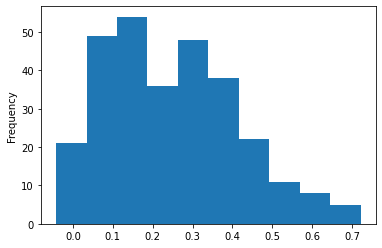

In [10]:
BS['EF'].plot.hist()

In [11]:
BS.to_pickle(f'{dataset}/ParsedBriefsummary.pkl')

# Magnetic vs Non Magnetic

In [12]:
EFFM = BS['EF'][Features.Mag == 'FM']

In [13]:
EFNM = BS['EF'][Features.Mag == 'NM']

In [14]:
EFFM.index = EFFM.index.str.replace('.FM', '')

In [15]:
EFNM.index = EFNM.index.str.replace('.NM', '')

In [16]:
BS['EF'][Features.StrucNames == 'fcc']

Mo_sv4.fcc-cubic.NM    0.421242
Mo_sv4.fcc-cubic.FM    0.420267
Fe_pv4.fcc-cubic.NM    0.079070
Fe_pv4.fcc-cubic.FM    0.148264
Name: EF, dtype: float64

In [17]:
BS['EF'][Features.StrucNames == 'bcc']

Mo_sv1.bcc.FM    0.000000
Mo_sv1.bcc.NM    0.000000
Fe_pv1.bcc.NM    0.393396
Fe_pv1.bcc.FM    0.000000
Name: EF, dtype: float64

In [18]:
BS['EF'][Features.StrucNames == 'hcp']

Mo_sv2.hcp.FM             0.436396
Mo_sv2.hcp.NM             0.436427
Fe_pv2.hcp.FM             0.189664
Fe_pv2.hcp.NM             0.000000
Fe_pv1Mo_sv1.hcp-AB.NM    0.260278
Fe_pv1Mo_sv1.hcp-AB.FM    0.295870
Name: EF, dtype: float64

In [19]:
DE_mag  = EFNM - EFFM 

In [20]:
DE_mag[ abs(DE_mag > 0.1)]

Fe_pv1.bcc                   0.393396
Fe_pv10Mo_sv2.C14-ABA        0.121951
Fe_pv10Mo_sv3.mu-BAAAB       0.111501
Fe_pv11Mo_sv2.mu-AAAAB       0.118357
Fe_pv12.C14                  0.164841
Fe_pv12Mo_sv1.mu-BAAAA       0.111115
Fe_pv14Mo_sv10.C36-AABAB     0.168965
Fe_pv14Mo_sv10.C36-AABBA     0.106243
Fe_pv18Mo_sv6.C36-AAAAB      0.244360
Fe_pv18Mo_sv6.C36-AAABA      0.162683
Fe_pv1Mo_sv1.B2-AB           0.132907
Fe_pv20Mo_sv4.C36-AABAA      0.124369
Fe_pv24.C36                  0.204949
Fe_pv28Mo_sv2.sigma-BAAAA    0.123198
Fe_pv30.sigma                0.107856
Fe_pv4Mo_sv9.mu-BBAAB        0.120165
Fe_pv5Mo_sv8.mu-ABAAB        0.143192
Fe_pv5Mo_sv8.mu-ABBAA        0.105419
Fe_pv6Mo_sv2.A15-AB          0.169993
Fe_pv7Mo_sv6.mu-ABAAA        0.101912
Fe_pv8.A15                   0.154134
Fe_pv8Mo_sv16.C36-AABBB      0.105233
Name: EF, dtype: float64

In [21]:
DE_mag[DE_mag < 0 ]

Fe_pv10Mo_sv14.C36-ABBBA     -0.034282
Fe_pv10Mo_sv14.C36-BBAAB     -0.014172
Fe_pv10Mo_sv14.C36-BBABA     -0.027213
Fe_pv10Mo_sv20.sigma-ABBAB   -0.009879
Fe_pv11Mo_sv2.mu-AAABA       -0.102201
Fe_pv11Mo_sv2.mu-AABAA       -0.021169
Fe_pv12Mo_sv12.C36-BBBAA     -0.029583
Fe_pv12Mo_sv17.chi-BBAB      -0.015647
Fe_pv12Mo_sv17.chi-BBBA      -0.029450
Fe_pv12Mo_sv18.sigma-BABAB   -0.001992
Fe_pv13Mo_sv16.chi-ABBA      -0.031924
Fe_pv14Mo_sv16.sigma-AABAB   -0.005138
Fe_pv16Mo_sv13.chi-BABA      -0.002927
Fe_pv16Mo_sv8.C36-BBAAA      -0.018901
Fe_pv1Mo_sv1.hcp-AB          -0.035592
Fe_pv1Mo_sv12.mu-ABBBB       -0.005391
Fe_pv1Mo_sv28.chi-ABBB       -0.002428
Fe_pv2.hcp                   -0.189664
Fe_pv24Mo_sv5.chi-BBAA       -0.006320
Fe_pv25Mo_sv4.chi-ABAA       -0.006054
Fe_pv2Mo_sv10.C14-BAB        -0.011312
Fe_pv2Mo_sv11.mu-BBBAB       -0.010931
Fe_pv2Mo_sv11.mu-BBBBA       -0.010929
Fe_pv2Mo_sv28.sigma-ABBBB    -0.004718
Fe_pv2Mo_sv6.D0_19-AB3       -0.017782
Fe_pv3Mo_sv1.L12-A3B     